<a href="https://colab.research.google.com/github/Mukeshburdak/diabetes-prediction/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [454]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [455]:
data=pd.read_csv("diabetes_prediction_dataset.csv")

In [456]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [457]:
data.replace({'Female': 0, 'Male': 1,'Other':2}, inplace=True)

<ipython-input-457-ddb3143f87b0>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Female': 0, 'Male': 1,'Other':2}, inplace=True)


In [458]:
data = data[data.smoking_history != "No Info"]

In [459]:
# set(df['smoking_history'])

In [460]:
data.replace({ 'current': 1, 'ever': 2, 'former': 3, 'never': 4, 'not current': 5}, inplace=True)

<ipython-input-460-e4461d99e847>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({ 'current': 1, 'ever': 2, 'former': 3, 'never': 4, 'not current': 5}, inplace=True)


In [461]:
data.describe()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,64184.000000,64184.000000,64184.000000,64184.000000,64184.000000,64184.000000,64184.000000,64184.000000,64184.000000
mean,0.394865,46.544112,0.097890,0.047037,3.395940,28.424120,5.564281,139.628225,0.109778
std,0.489208,19.540334,0.297169,0.211719,1.197046,6.516199,1.095519,42.165904,0.312615
min,0.000000,0.160000,0.000000,0.000000,1.000000,10.080000,3.500000,80.000000,0.000000
25%,0.000000,31.000000,0.000000,0.000000,3.000000,24.600000,4.800000,100.000000,0.000000
50%,0.000000,47.000000,0.000000,0.000000,4.000000,27.320000,5.800000,140.000000,0.000000
75%,1.000000,61.000000,0.000000,0.000000,4.000000,31.100000,6.200000,159.000000,0.000000
max,2.000000,80.000000,1.000000,1.000000,5.000000,91.820000,9.000000,300.000000,1.000000


In [462]:
if 'bmi' in data.columns:
    data['bmi'] = data['bmi'].replace(0, data['bmi'].mean())
else:
    print("Warning: 'bmi' column not found in the DataFrame.")

In [463]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64184 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               64184 non-null  int64  
 1   age                  64184 non-null  float64
 2   hypertension         64184 non-null  int64  
 3   heart_disease        64184 non-null  int64  
 4   smoking_history      64184 non-null  int64  
 5   bmi                  64184 non-null  float64
 6   HbA1c_level          64184 non-null  float64
 7   blood_glucose_level  64184 non-null  int64  
 8   diabetes             64184 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 4.9 MB


In [464]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0
5,0,20.0,0,0,4,27.32,6.6,85,0
...,...,...,...,...,...,...,...,...,...
99992,0,26.0,0,0,4,34.34,6.5,160,0
99993,0,40.0,0,0,4,40.69,3.5,155,0
99997,1,66.0,0,0,3,27.83,5.7,155,0
99998,0,24.0,0,0,4,35.42,4.0,100,0


In [465]:
data.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [466]:
data.duplicated().sum()

np.int64(925)

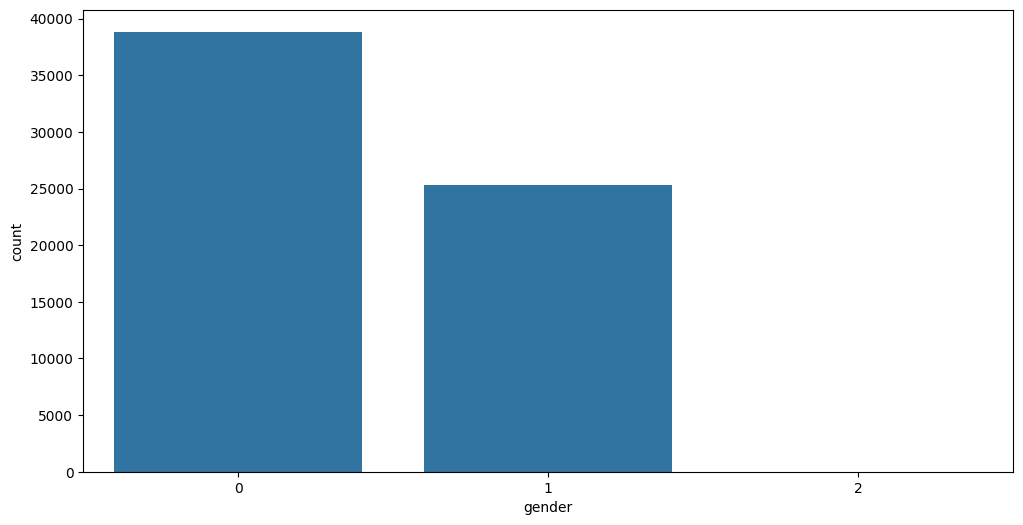

In [467]:
#data visualisation
plt.figure(figsize=(12,6))
sns.countplot(x="gender", data=data)
plt.show()

In [468]:
data.iloc[9634,:]

,14909
gender,0.00
age,42.00
hypertension,0.00
heart_disease,0.00
smoking_history,4.00
bmi,31.01
HbA1c_level,6.20
blood_glucose_level,85.00
diabetes,0.00


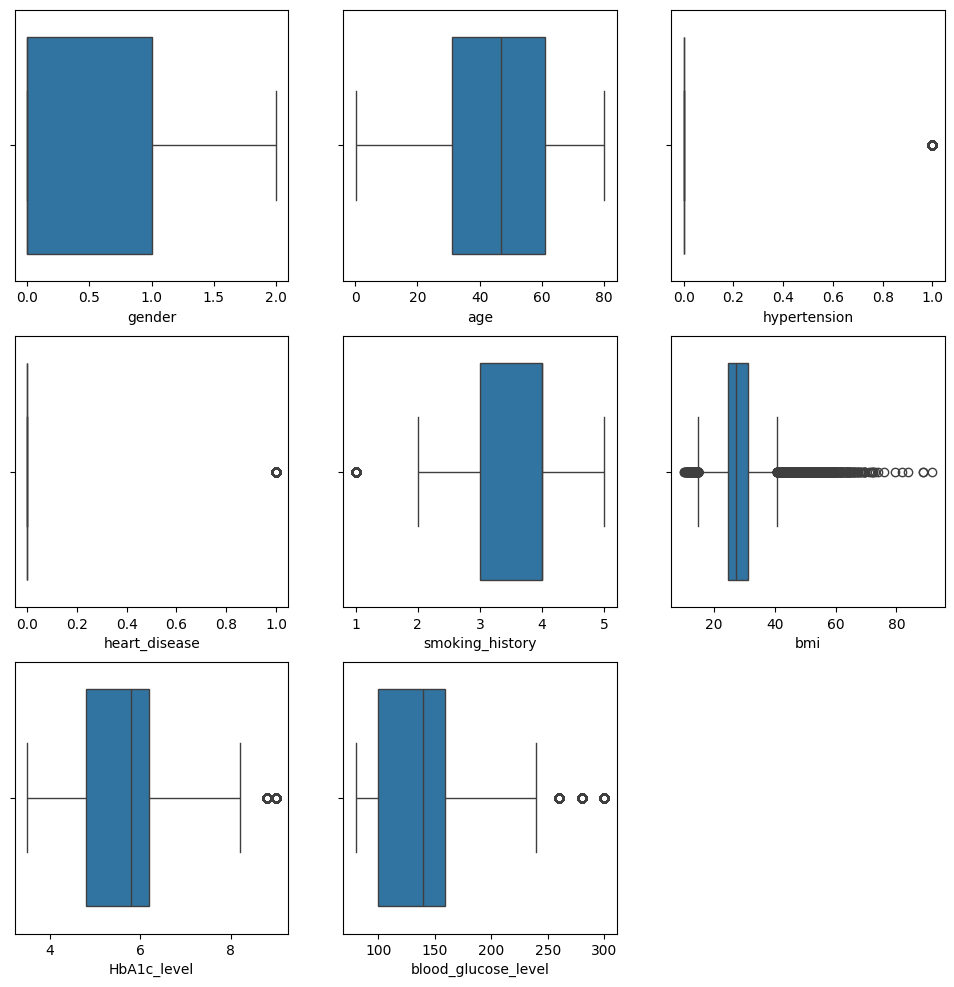

In [469]:
#observing outliers
plt.figure(figsize=(12,12))
for i,col in enumerate(data.columns[:-1]):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=col,data=data)
plt.show()


In [470]:
data.keys()

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

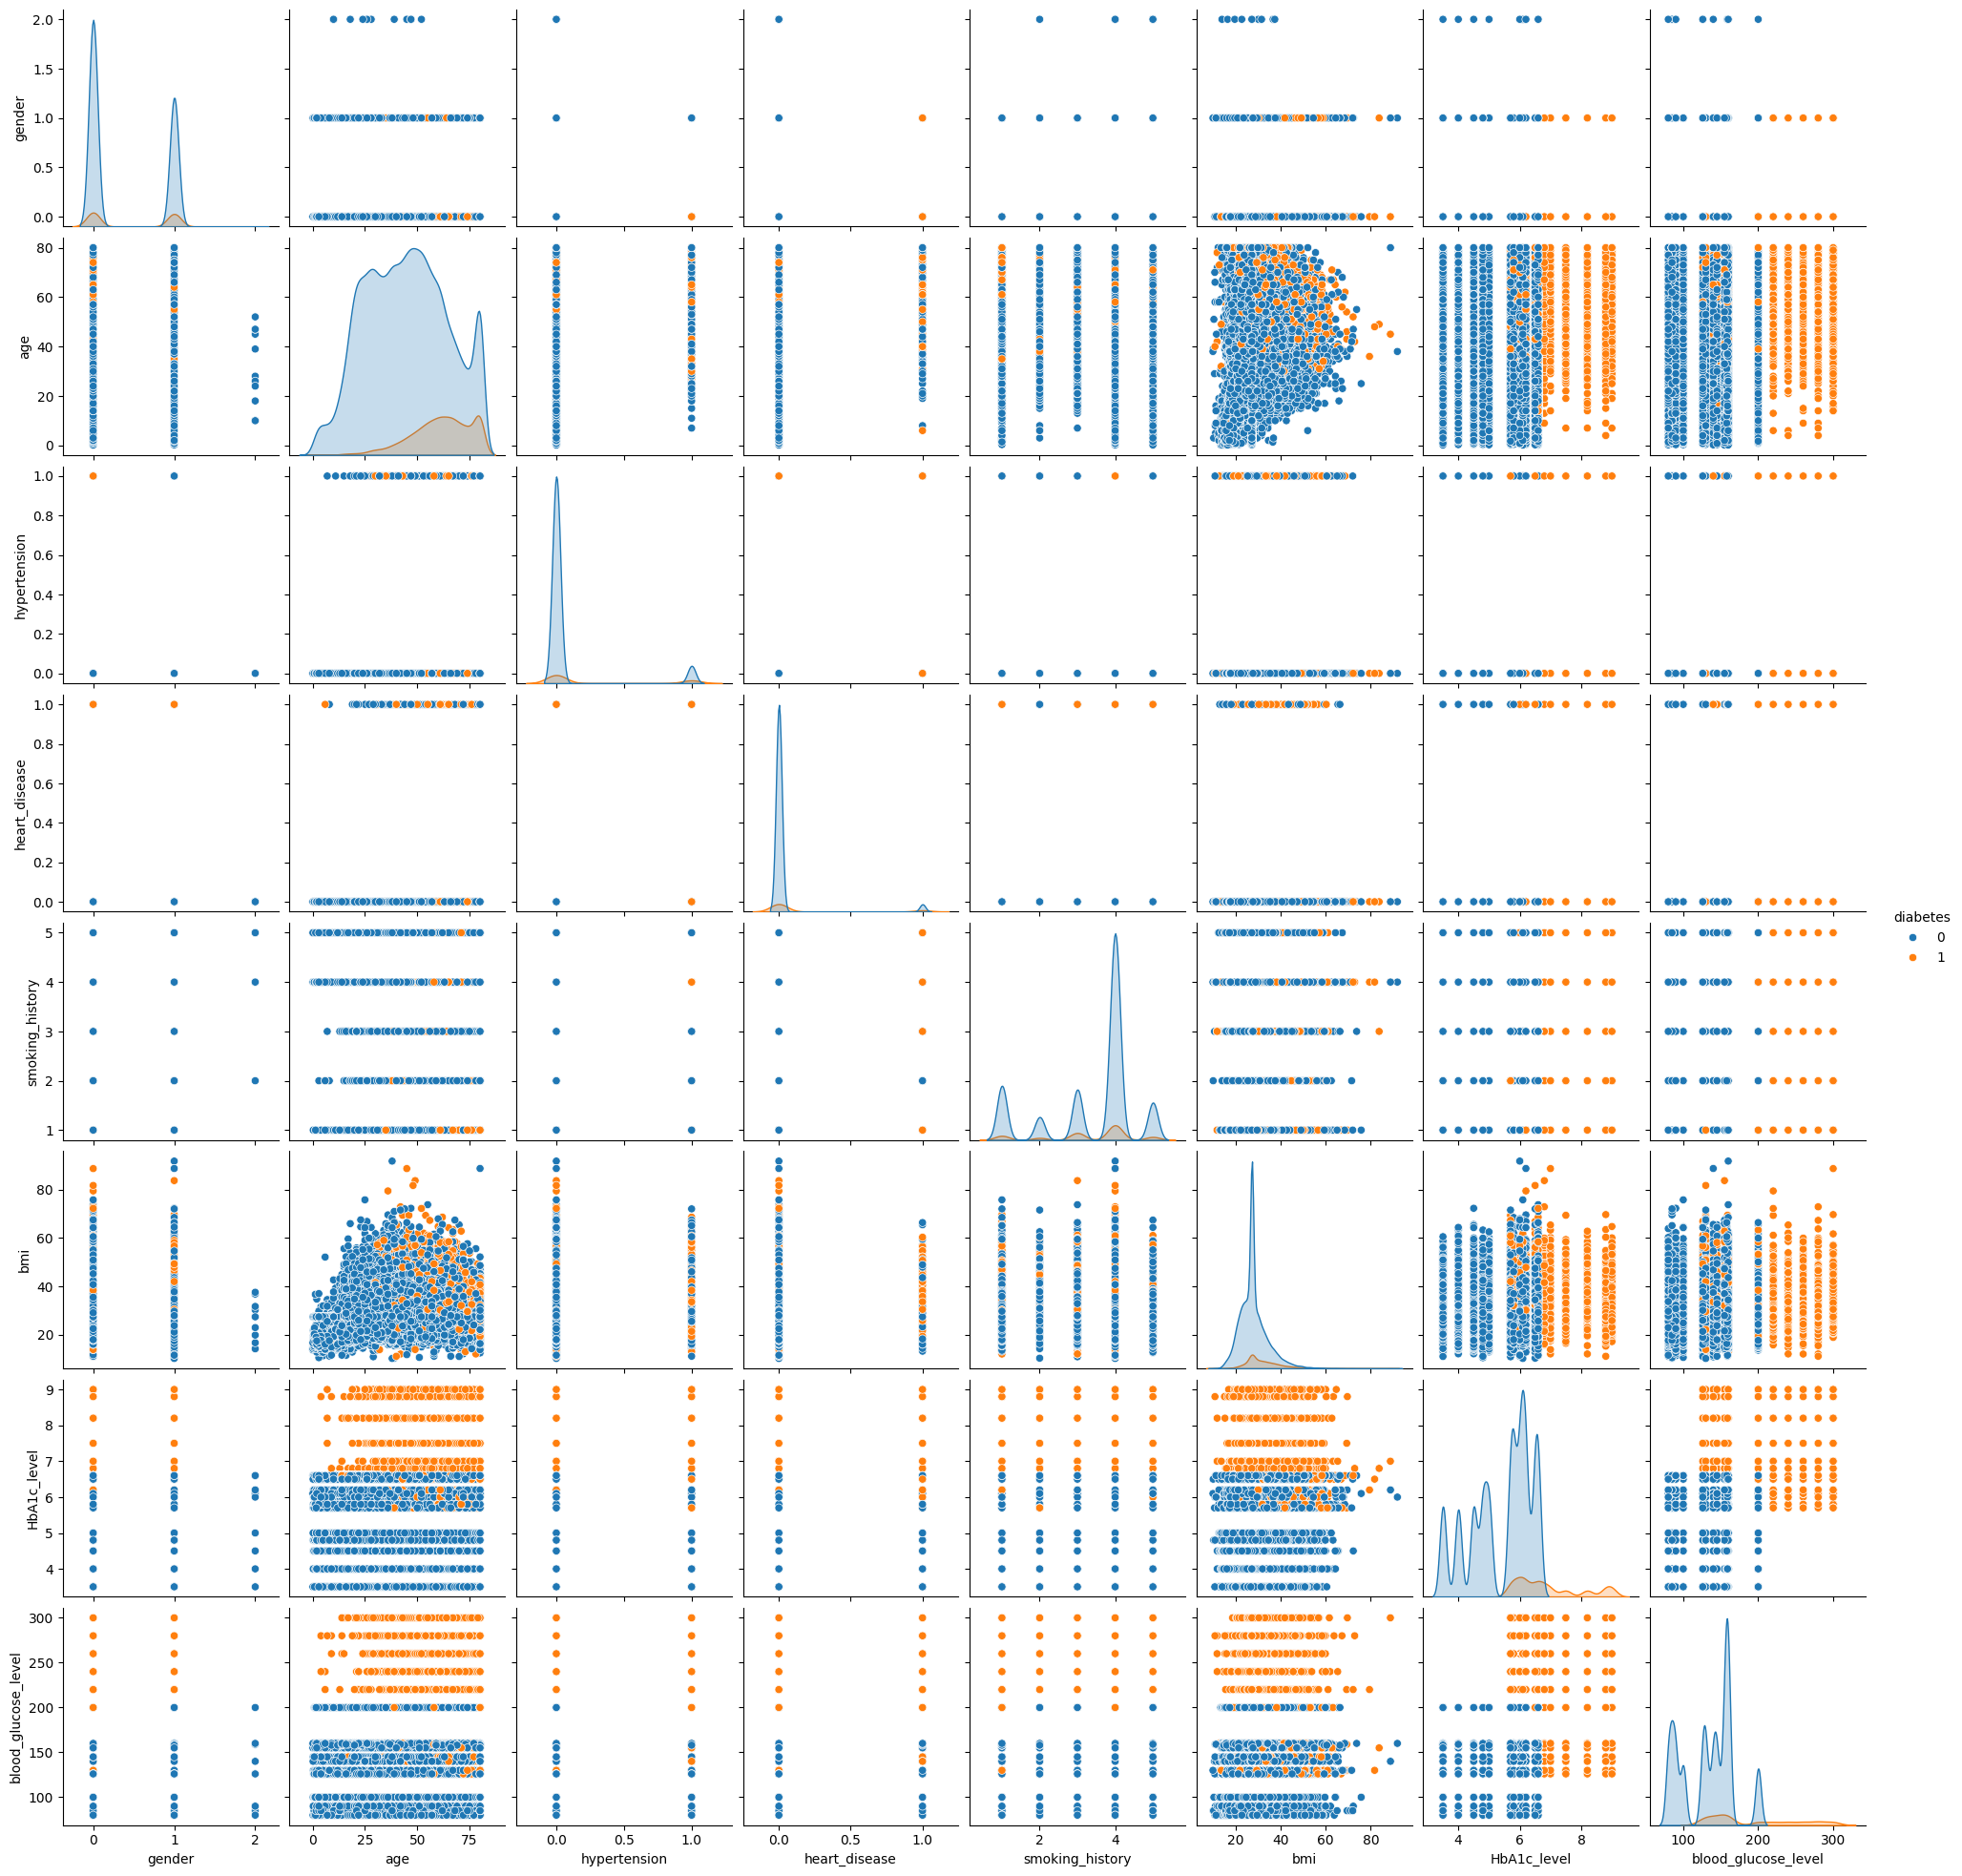

In [471]:
sns.pairplot(data, hue = 'diabetes')
plt.show()


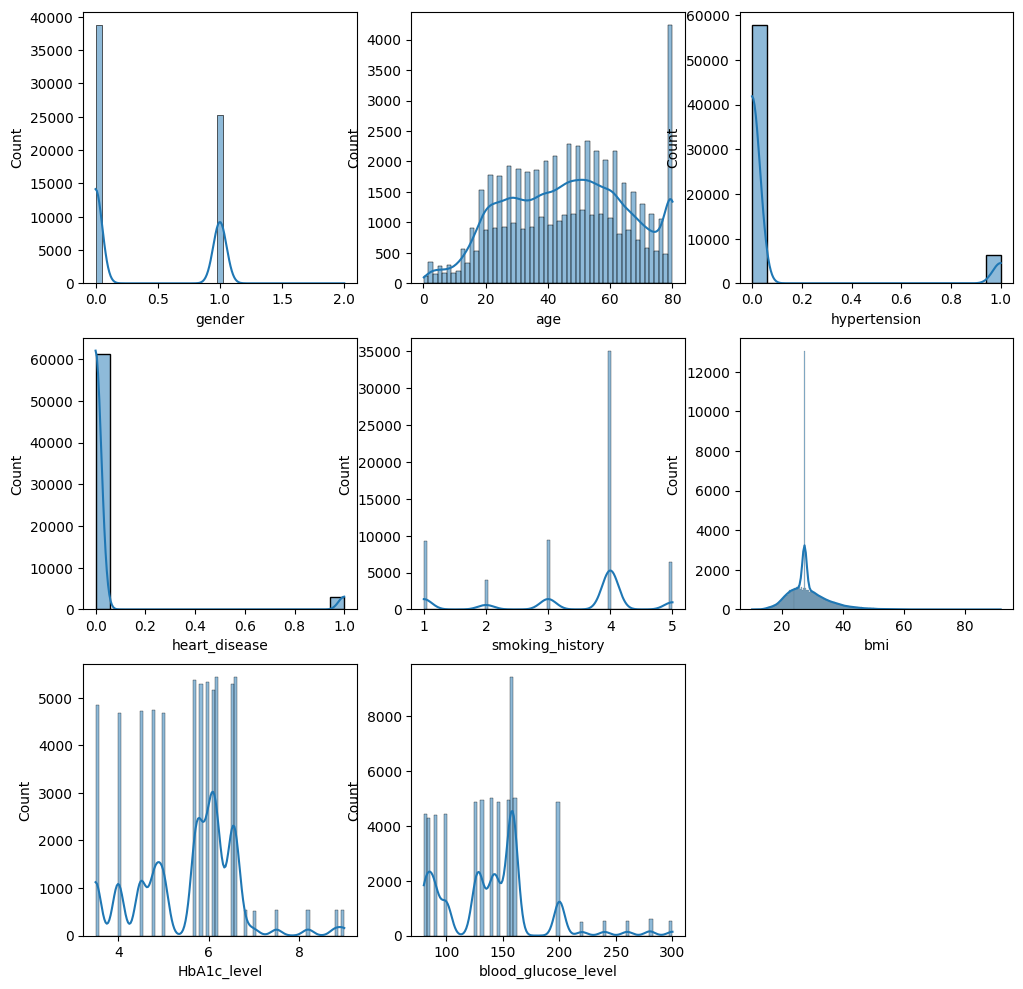

In [472]:
plt.figure(figsize=(12,12))
for i,col in enumerate(data.columns[:-1]):
  plt.subplot(3,3,i+1)
  sns.histplot(x=col,data=data,kde=True)
plt.show()

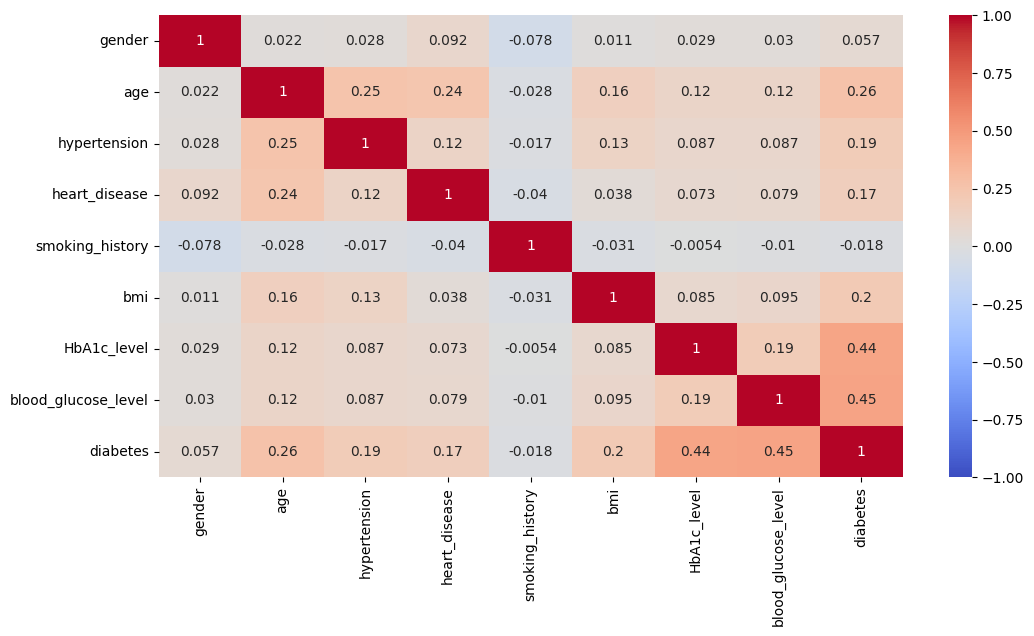

In [473]:
plt.figure(figsize=(12,6))
sns.heatmap(data.corr(),annot=True ,vmin=-1,vmax=1,cmap='coolwarm')
plt.show()

In [474]:
k=list(data.keys())
k.pop(-1)
k

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level']

In [475]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = pd.DataFrame(sc_X.fit_transform(data.drop(["diabetes"],axis= 1),),columns=k)

In [476]:
X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,-0.807158,1.712158,-0.329413,4.501113,0.50463,-0.496324,0.945421,0.008817
1,1.236979,-0.949025,-0.329413,-0.222167,0.50463,-0.169444,0.123887,0.435706
2,-0.807158,-0.539612,-0.329413,-0.222167,-2.00156,-0.763353,-0.515085,0.364557
3,1.236979,1.507452,3.035705,4.501113,-2.00156,-1.271322,-0.697648,0.364557
4,-0.807158,-1.358437,-0.329413,-0.222167,0.50463,-0.169444,0.945421,-1.295565


In [477]:
y=data['diabetes']

In [478]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [479]:
from sklearn.neighbors import KNeighborsClassifier

test_scores =[]
train_scores=[]
for i in range(5,15):
  knn=KNeighborsClassifier(i)
  knn.fit(X_train,y_train)

  train_scores.append(knn.score(X_train,y_train))
  test_scores.append(knn.score(X_test,y_test))

In [480]:
max_train_score=max(train_scores)
train_scores_index = [i+5  for i , v in enumerate(train_scores) if v ==max_train_score]
print("Max Train score {} % and k ={}".format(max_train_score*100 , list(map(lambda x:x+1 ,train_scores_index))))

Max Train score 96.12268518518519 % and k =[6]


In [481]:
max_test_score=max(test_scores)
test_scores_index = [i+5  for i , v in enumerate(test_scores) if v ==max_test_score]
print("Max Test score {} % and k ={}".format(max_test_score*100 , list(map(lambda x:x+1 ,test_scores_index))))

Max Test score 94.74449522226838 % and k =[14]


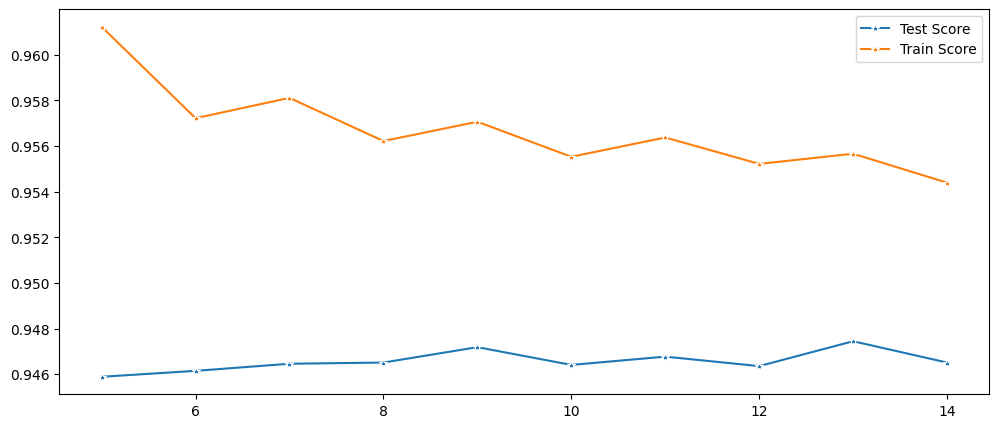

In [482]:
plt.figure(figsize=(12,5))
p = sns.lineplot(x=range(5,15), y=test_scores, marker='*', label='Test Score')
p = sns.lineplot(x=range(5,15), y=train_scores, marker='*', label='Train Score')

In [483]:
df = data

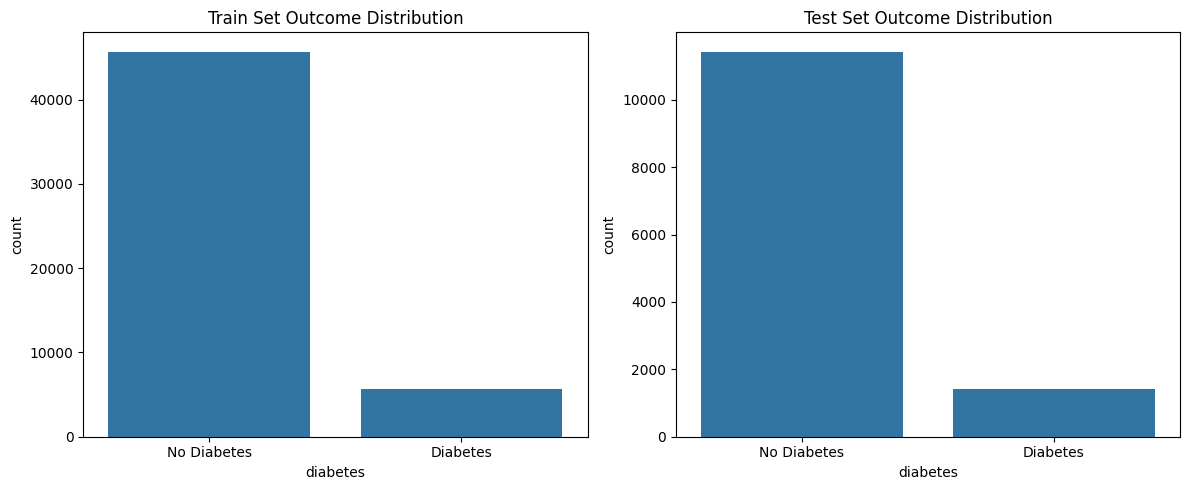

In [484]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split the dataset into train and test (80% train, 20% test)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['diabetes'])

# 1. Countplot: Comparing target class distribution in train/test
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='diabetes', data=train_df)
plt.title("Train Set Outcome Distribution")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])

plt.subplot(1, 2, 2)
sns.countplot(x='diabetes', data=test_df)
plt.title("Test Set Outcome Distribution")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

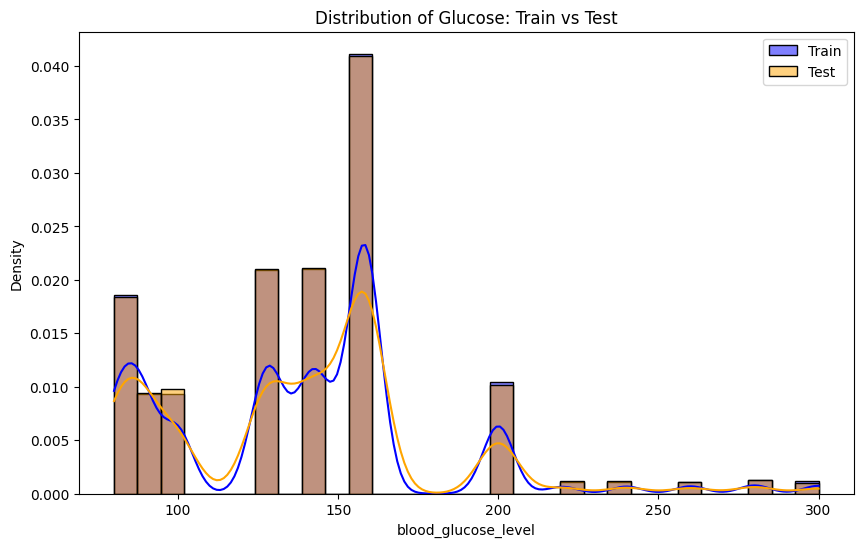

In [485]:
# 2. Histplot: Distribution of Glucose in train vs test
plt.figure(figsize=(10, 6))
sns.histplot(train_df['blood_glucose_level'], color='blue', label='Train', kde=True, stat="density", bins=30)
sns.histplot(test_df['blood_glucose_level'], color='orange', label='Test', kde=True,stat="density", bins=30)
plt.title("Distribution of Glucose: Train vs Test")
plt.legend()
plt.show()

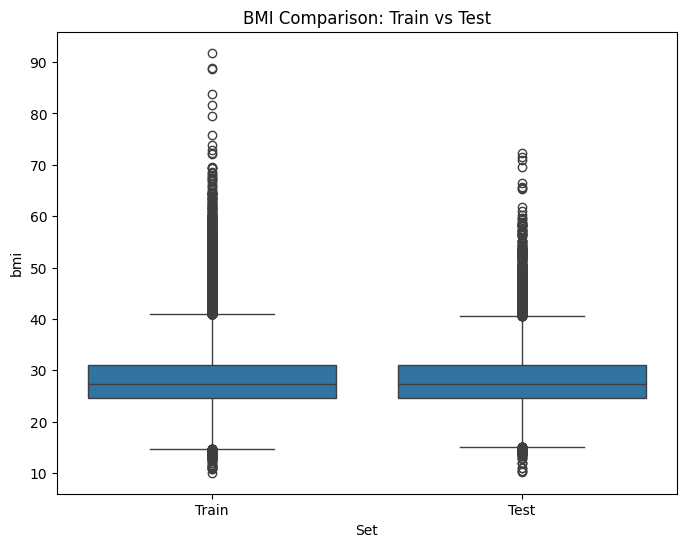

In [486]:
# 3. Boxplot: Compare BMI in Train vs Test
train_df['Set'] = 'Train'
test_df['Set'] = 'Test'
combined_df = pd.concat([train_df, test_df])

plt.figure(figsize=(8, 6))
sns.boxplot(x='Set', y='bmi', data=combined_df)
plt.title("BMI Comparison: Train vs Test")
plt.show()

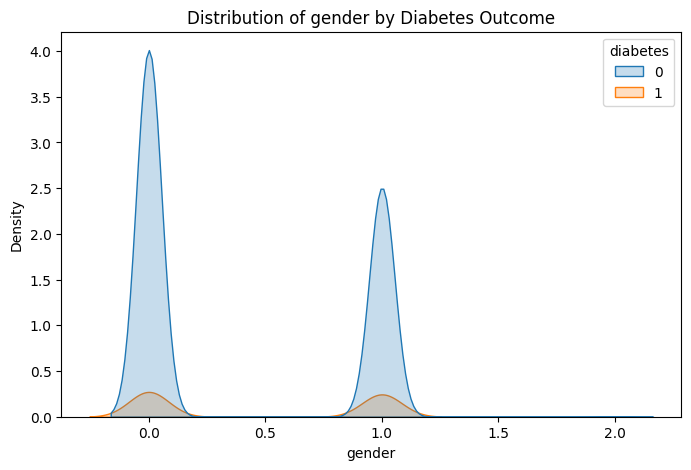

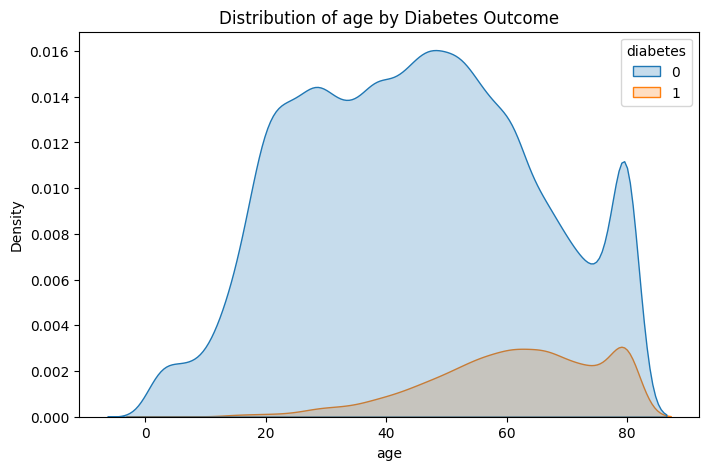

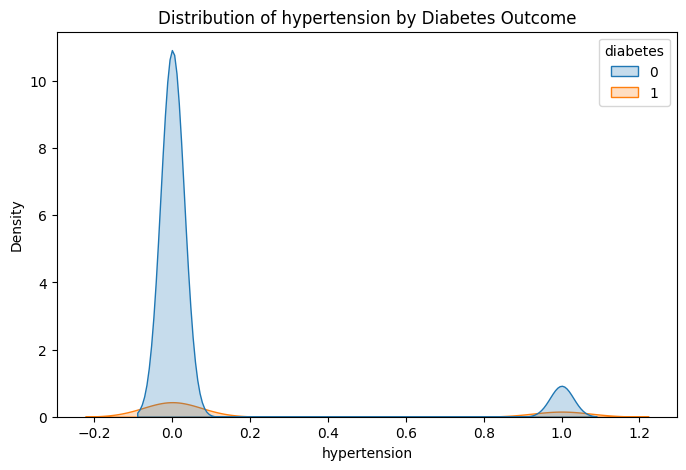

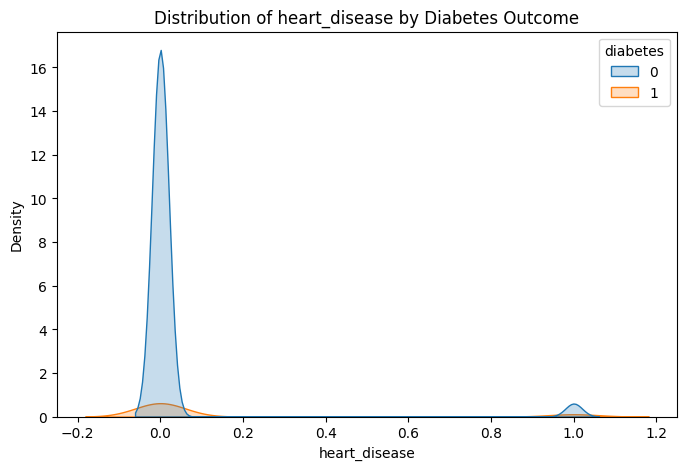

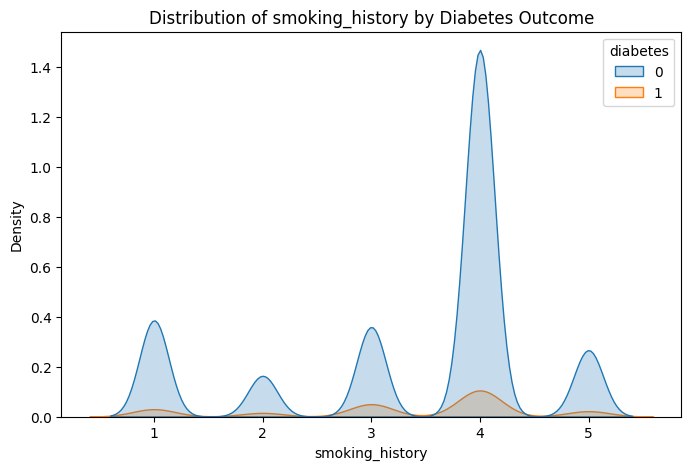

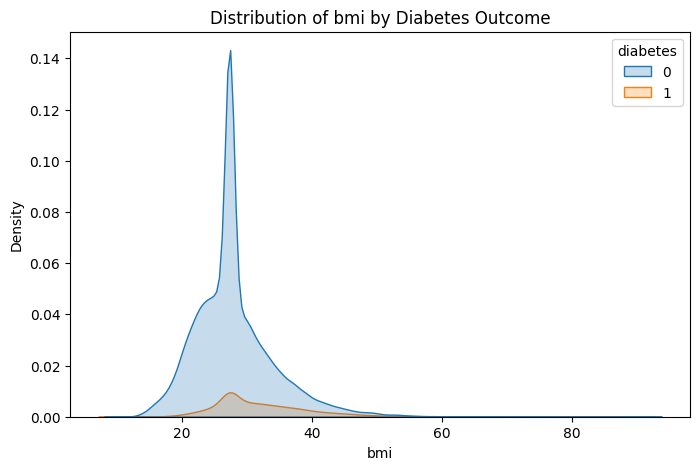

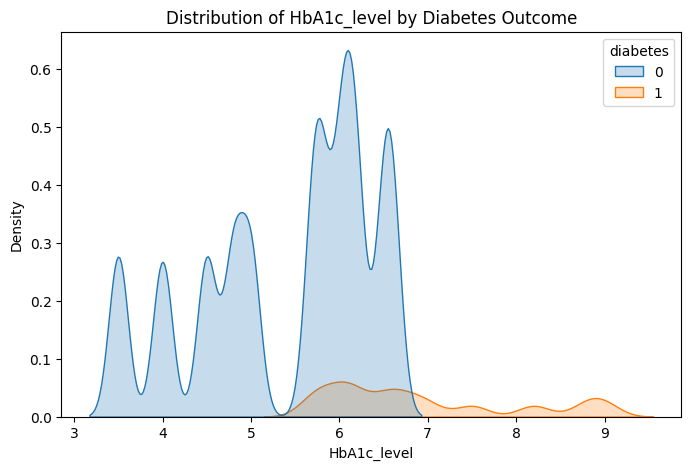

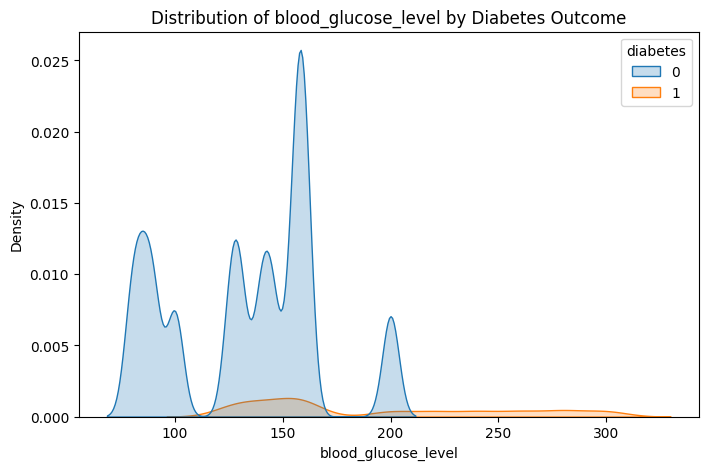

In [487]:
# Features to compare
features = k

for feature in features:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=feature, hue='diabetes', fill=True)
    plt.title(f'Distribution of {feature} by Diabetes Outcome')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()


In [488]:
knn_model = KNeighborsClassifier(n_neighbors=13)

In [489]:
knn_model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=13)

In [490]:
y_pred=knn_model.predict(X_test)

In [491]:
confusion_matrix(y_test,y_pred)

array([[17036,    79],
       [  933,  1208]])

In [492]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
accuracy_score(y_test, y_pred)*100

94.74449522226838

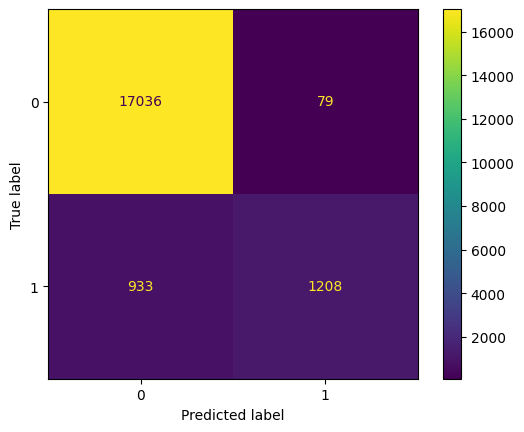

In [493]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()